# Le volley-ball aux Jeux Olympiques 2024 : un sport mondialisé mais inégalitaire

Les Jeux Olympiques de Paris 2024 ont réuni 24 équipes nationales, hommes et femmes confondus, issues de quatre continents différents, témoignant d'une internationalisation croissante de la discipline.

Pourtant, cette apparente mondialisation présente des inégalités profondes qui structurent ce sport à l'échelle internationale. Dans le cadre 
de la problématique générale de ce travail, qui interroge dans quelle mesure les Jeux Olympiques reflètent et influencent les inégalités sociales, politiques et de genre, le volleyball constitue un terrain d'analyse particulièrement révélateur.

À travers une analyse statistique du dataset des matchs de volleyball des JO de Paris 2024, nous examinerons successivement les inégalités selon le genre dans la représentation et les performances des nations, puis les inégalités géopolitiques qui structurent la hiérarchie sportive mondiale dans cette discipline.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn
seaborn.set_style("white")
import os 
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.stats import chi2_contingency
from sklearn import metrics

In [2]:
volley = pd.read_csv("DATASETS_PARIS_2024_-_VOLLEY.csv").dropna()

volley.shape

(104, 20)

In [3]:
volley.head()

,date,stage_code,event_code,event_name,event_stage,stage,stage_status,gender,discipline_name,discipline_code,venue,participant_code,participant_name,participant_type,participant_country_code,participant_country,result,result_type,result_WLT,start_order
0,2024-07-27T22:38:19+02:00,VVOMTEAM6-------------GPC-000200--,VVOMTEAM6,Men,Men's Preliminary Round - Pool C,Preliminary Round - Pool C,FINISHED,M,Volleyball,VVO,South Paris Arena 1,VVOMTEAM6---USA01,United States of America,Team,USA,United States,3,POINTS,W,1
1,2024-07-27T22:38:19+02:00,VVOMTEAM6-------------GPC-000200--,VVOMTEAM6,Men,Men's Preliminary Round - Pool C,Preliminary Round - Pool C,FINISHED,M,Volleyball,VVO,South Paris Arena 1,VVOMTEAM6---ARG01,Argentina,Team,ARG,Argentina,0,POINTS,L,2
2,2024-07-30T10:21:58+02:00,VVOMTEAM6-------------GPB-000300--,VVOMTEAM6,Men,Men's Preliminary Round - Pool B,Preliminary Round - Pool B,FINISHED,M,Volleyball,VVO,South Paris Arena 1,VVOMTEAM6---ITA01,Italy,Team,ITA,Italy,3,POINTS,W,1
3,2024-07-30T10:21:58+02:00,VVOMTEAM6-------------GPB-000300--,VVOMTEAM6,Men,Men's Preliminary Round - Pool B,Preliminary Round - Pool B,FINISHED,M,Volleyball,VVO,South Paris Arena 1,VVOMTEAM6---EGY01,Egypt,Team,EGY,Egypt,0,POINTS,L,2
4,2024-07-30T15:11:20+02:00,VVOMTEAM6-------------GPC-000300--,VVOMTEAM6,Men,Men's Preliminary Round - Pool C,Preliminary Round - Pool C,FINISHED,M,Volleyball,VVO,South Paris Arena 1,VVOMTEAM6---USA01,United States of America,Team,USA,United States,3,POINTS,W,1


## 1. Inégalités selon le genre

Le volleyball est l'un des rares sports olympiques à proposer un format de compétition strictement identique pour les hommes et les femmes. Cette 
symétrie apparente invite à interroger ce qui se cache derrière l'égalité de format : les nations participantes sont-elles les mêmes ? Les performances sont-elles comparables ? À travers une analyse statistique des matchs du tournoi de Paris 2024, nous chercherons à déterminer dans quelle mesure 
cette parité de format reflète ou masque des inégalités de genre plus profondes.

### 1.1 Statistiques descriptives

In [4]:
# Nombre de matchs par genre
volley["gender"].value_counts()

gender
M    52
W    52
Name: count, dtype: int64

Les deux compétitions sont parfaitement symétriques : 52 matchs masculins et 52 matchs féminins. 
Cette égalité de format est une avancée notable en termes de parité de genre dans le sport olympique. Cependant, comme nous le verrons, cette symétrie apparente masque des inégalités de représentation nationale et de performance selon le genre.

In [5]:
# Nombre de pays participants par genre
volley.groupby("gender")["participant_country"].value_counts()

gender  participant_country
M       France                 6
        Italy                  6
        Poland                 6
        United States          6
        Brazil                 4
        Germany                4
        Japan                  4
        Slovenia               4
        Argentina              3
        Canada                 3
        Egypt                  3
        Serbia                 3
W       Brazil                 6
        Italy                  6
        Türkiye                6
        United States          6
        China                  4
        Dominican Republic     4
        Poland                 4
        Serbia                 4
        France                 3
        Japan                  3
        Kenya                  3
        Netherlands            3
Name: count, dtype: int64

Ce tableau révèle le nombre de matchs joués par chaque pays selon le genre, ce qui reflète directement leur progression dans le tournoi. Les pays ayant joué 6 matchs sont ceux ayant atteint la finale, en masculin il s'agit de la France, l'Italie, la Pologne et les États-Unis, et en féminin du Brésil, l'Italie, la Turquie et les États-Unis. Les pays ayant joué 4 matchs ont atteint les quarts de finale, tandis que ceux ayant joué 3 matchs ont été éliminés dès la phase de groupes.

On observe également que seuls 7 pays sont présents dans les deux tournois, à savoir le Brésil, la France, l'Italie, le Japon, la Pologne, la Serbie et les États-Unis. Ce sont les grandes puissances historiques du volleyball mondial, ce qui suggère une concentration des performances indépendante du genre. En revanche, 5 pays n'apparaissent qu'en masculin et 5 pays qu'en féminin, traduisant des dynamiques de développement sportif différentes selon le genre au sein de ces nations.

#### Visualisation du nombre de matchs joués par pays et par genre

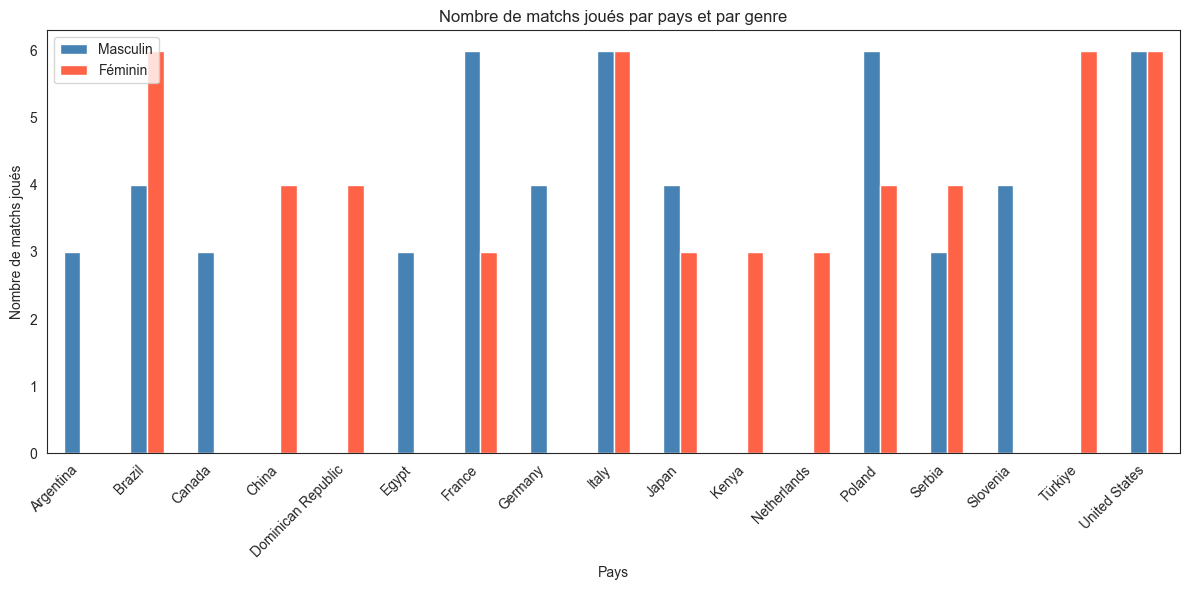

In [6]:
# Nombre de matchs joués par pays et par genre
matchs_par_pays = volley.groupby(["participant_country", "gender"])["result_WLT"].count().unstack()

# Diagramme en barres groupées
matchs_par_pays.plot(kind="bar", figsize=(12, 6), color=["steelblue", "tomato"])
plt.title("Nombre de matchs joués par pays et par genre")
plt.xlabel("Pays")
plt.ylabel("Nombre de matchs joués")
plt.legend(["Masculin", "Féminin"])
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Ce graphique illustre le nombre de matchs joués par chaque pays selon le genre, ce qui reflète directement leur niveau de progression dans le tournoi. Plus un pays a joué de matchs, plus il est allé loin dans la compétition.

On observe que les pays ayant joué 6 matchs, soit le maximum possible, sont ceux ayant atteint la finale. En masculin il s'agit de la France, l'Italie, 
la Pologne et les États-Unis, et en féminin du Brésil, l'Italie, la Pologne et les États-Unis. Ces nations confirment leur statut de grandes puissances du volleyball mondial dans les deux genres.

Le graphique met également en évidence les pays absents d'un tournoi, représentés par une seule barre. C'est le cas de la Chine, du Kenya et 
des Pays-Bas, présents uniquement en féminin, ou encore de l'Argentine, du Canada et de l'Égypte, présents uniquement en masculin. Cette asymétrie confirme que la représentation nationale varie significativement selon le genre, traduisant des inégalités de développement sportif au sein même de ces nations.

### 1.2 Test du Chi² : le résultat est-il indépendant du genre ?

Le test du Chi² d'indépendance permet de tester si deux variables qualitatives 
sont liées ou non. Ici, on teste si le résultat (victoire/défaite) est indépendant 
du genre du tournoi (masculin/féminin).

L'hypothèse nulle (H0) est que le résultat est indépendant du genre.
L'hypothèse alternative (H1) est que le résultat est lié au genre.

In [7]:
# Tableau de contingence genre x résultat
contingence = pd.crosstab(volley["gender"], volley["result_WLT"], margins=True)
contingence

result_WLT,L,W,All
gender,,,
M,26,26,52
W,26,26,52
All,52,52,104


In [8]:
# Test du Chi²
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(pd.crosstab(volley["gender"], volley["result_WLT"]))

print(f"Statistique Chi² : {chi2:.4f}")
print(f"Degrés de liberté : {dof}")
print(f"p-valeur : {p:.4f}")

Statistique Chi² : 0.0000
Degrés de liberté : 1
p-valeur : 1.0000


Le test du Chi² obtient une statistique de 0.0000 et une p-valeur de 1.0000, ce qui est largement supérieur au seuil de signification de 0.05. On ne peut 
donc pas rejeter l'hypothèse nulle H0 : le résultat (victoire/défaite) est indépendant du genre du tournoi.

Ce résultat confirme statistiquement ce que nous avions observé visuellement : les deux tournois sont parfaitement symétriques en termes de distribution des victoires et des défaites. Pour chaque match, il y a toujours un gagnant et un perdant, quel que soit le genre.

Cela signifie que la parité de format entre les tournois masculin et féminin est totale. Les inégalités de genre dans le volleyball olympique ne se situent donc pas dans le format de la compétition, mais bien dans la représentation des nations participantes, comme nous l'avons montré précédemment.

#### Visualisation du taux de victoire par pays et par genre

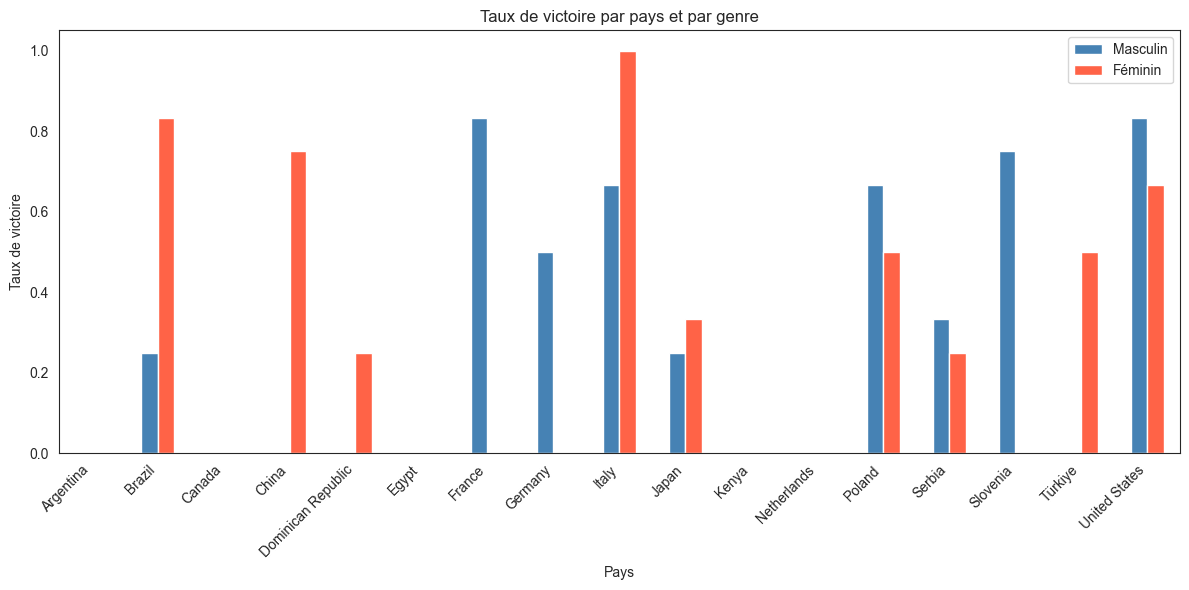

In [9]:
# Calcul du taux de victoire par pays et par genre
volley["victoire"] = volley["result_WLT"].map({"W": 1, "L": 0})

taux_victoire = volley.groupby(["participant_country", "gender"])["victoire"].mean().unstack()

# Diagramme en barres groupées
taux_victoire.plot(kind="bar", figsize=(12, 6), color=["steelblue", "tomato"])
plt.title("Taux de victoire par pays et par genre")
plt.xlabel("Pays")
plt.ylabel("Taux de victoire")
plt.legend(["Masculin", "Féminin"])
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Ce graphique illustre les taux de victoire par pays et par genre et permet de mettre en évidence plusieurs tendances intéressantes.

Certains pays affichent des performances élevées dans les deux tournois, comme l'Italie, la France, le Brésil et les États-Unis, confirmant leur statut de 
grandes puissances du volleyball mondial indépendamment du genre.

En revanche, on observe des écarts importants pour certains pays. L'Italie présente un taux de victoire de 1.0 en masculin contre 0.66 en féminin, tandis 
que la France affiche 0.83 en féminin contre un taux plus faible en masculin. Ces écarts suggèrent que certaines nations investissent davantage dans le 
développement d'un genre plutôt que de l'autre.

Enfin, les pays présents dans un seul tournoi, comme le Kenya, les Pays-Bas ou l'Argentine, affichent généralement des taux de victoire très faibles voire 
nuls, ce qui confirme que leur qualification relevait davantage d'une opportunité que d'une tradition sportive établie dans cette discipline.

Ces observations viennent compléter le résultat du test du Chi² : si le format est symétrique, les performances révèlent quant à elles des inégalités réelles entre les nations selon le genre.

## 2. Inégalités selon le contexte politique et géopolitique

Au-delà de la dimension sportive, les résultats des Jeux Olympiques peuvent être lus comme le reflet de dynamiques géopolitiques et économiques mondiales. Quelles nations dominent la compétition ? Cette domination est-elle concentrée entre un petit nombre de pays ? À travers une analyse des performances par continent et un clustering des nations participantes, nous chercherons à montrer que les inégalités sportives reproduisent des inégalités structurelles plus larges entre les nations.

### 2.1 Statistiques descriptives

In [10]:
# Nombre de victoires par pays toutes genres confondus
volley["victoire"] = volley["result_WLT"].map({"W": 1, "L": 0})
victoires_pays = volley.groupby("participant_country")["victoire"].sum().sort_values(ascending=False)
victoires_pays

participant_country
Italy                 10
United States          9
Poland                 6
Brazil                 6
France                 5
Türkiye                3
Slovenia               3
China                  3
Japan                  2
Germany                2
Serbia                 2
Dominican Republic     1
Argentina              0
Egypt                  0
Canada                 0
Netherlands            0
Kenya                  0
Name: victoire, dtype: int64

Le classement des pays par nombre de victoires révèle une concentration très marquée des performances. L'Italie domine largement avec 10 victoires, suivie 
des États-Unis avec 9 victoires et de la Pologne et du Brésil avec 6 victoires chacun. Ces quatre pays captent à eux seuls la grande majorité des victoires 
du tournoi.

On observe ainsi une fracture nette entre un groupe restreint de nations dominantes, toutes issues d'Europe ou d'Amérique, et un groupe de nations 
participantes mais peu compétitives, suggérant des inégalités structurelles profondes dans le développement du volleyball à l'échelle mondiale.

In [11]:
# Résumé statistique des victoires par pays
victoires_pays.describe()

count    17.000000
mean      3.058824
std       3.151797
min       0.000000
25%       0.000000
50%       2.000000
75%       5.000000
max      10.000000
Name: victoire, dtype: float64

Le résumé statistique des victoires par pays confirme la concentration observée précédemment. Sur les 17 pays participants, la moyenne est de 3.06 victoires par pays, mais cette moyenne masque une forte dispersion avec un écart-type de 3.15, presque aussi élevé que la moyenne elle-même.

La médiane est de seulement 2 victoires, ce qui signifie que la moitié des pays ont remporté 2 matchs ou moins. Le premier quartile est à 0, indiquant qu'au moins un quart des pays n'a remporté aucune victoire. À l'opposé, le maximum est de 10 victoires, ce qui illustre l'écart considérable entre les nations les plus performantes et les moins performantes.

Cette forte dispersion confirme l'existence d'inégalités structurelles profondes entre les nations participantes, que nous allons approfondir à travers une analyse de clustering dans la partie suivante.

In [12]:
# Attribution des pays à leur continent
continent = {
    "United States": "Amérique", "Brazil": "Amérique", "Argentina": "Amérique",
    "Canada": "Amérique", "Dominican Republic": "Amérique",
    "France": "Europe", "Italy": "Europe", "Poland": "Europe",
    "Germany": "Europe", "Serbia": "Europe", "Slovenia": "Europe",
    "Netherlands": "Europe",
    "Japan": "Asie", "China": "Asie", "Türkiye": "Asie",
    "Egypt": "Afrique", "Kenya": "Afrique"
}
volley["continent"] = volley["participant_country"].map(continent)

# Nombre de victoires par continent
volley.groupby("continent")["victoire"].sum().sort_values(ascending=False)

continent
Europe      28
Amérique    16
Asie         8
Afrique      0
Name: victoire, dtype: int64

La répartition des victoires par continent révèle une domination très nette de l'Europe avec 28 victoires, suivie de l'Amérique avec 16 victoires et de 
l'Asie avec 8 victoires. L'Afrique, représentée par le Kenya et l'Égypte, n'enregistre quant à elle aucune victoire.

Ces résultats mettent en évidence une hiérarchie géopolitique claire dans le volleyball olympique. L'Europe et l'Amérique concentrent à elles deux 84% des 
victoires du tournoi, tandis que l'Asie reste compétitive mais dans une moindre mesure. L'absence totale de victoires africaines illustre quant à elle les 
inégalités de développement sportif entre les continents, probablement liées à des différences de ressources économiques, d'infrastructures sportives et 
de traditions dans cette discipline.

#### Visualisation du nombre de victoires par continent

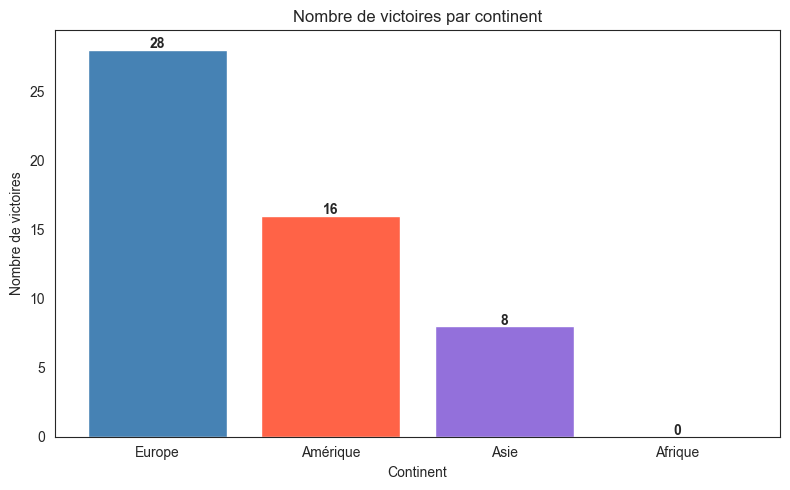

In [13]:
# Visualisation du nombre de victoires par continent
victoires_continent = volley.groupby("continent")["victoire"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(victoires_continent.index, victoires_continent.values, color=["steelblue", "tomato", "mediumpurple", "seagreen"])
plt.title("Nombre de victoires par continent")
plt.xlabel("Continent")
plt.ylabel("Nombre de victoires")
for i, v in enumerate(victoires_continent.values):
    plt.text(i, v + 0.1, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

Le graphique confirme visuellement la domination sans partage de l'Europe et de l'Amérique dans le volleyball olympique. L'Europe arrive en tête avec 28 
victoires, soit presque le double de l'Amérique qui en totalise 16. L'Asie reste présente avec 8 victoires, tandis que l'Afrique n'en enregistre aucune.

Cette hiérarchie continentale illustre des inégalités structurelles profondes dans le développement du volleyball à l'échelle mondiale. Les nations européennes et américaines bénéficient de traditions sportives anciennes, de ressources économiques importantes et d'infrastructures développées, ce qui se traduit directement par des performances supérieures sur la scène olympique.

À l'inverse, l'absence totale de victoires africaines interroge sur les conditions d'accès au sport de haut niveau pour ces nations et sur les inégalités de développement sportif entre les continents.

### 2.2 Clustering : concentration des victoires selon les zones géographiques

La Classification Ascendante Hiérarchique (CAH) permet de regrouper les pays 
selon leurs profils de performance. Elle part des individus les plus proches 
pour les regrouper progressivement en clusters homogènes. Le dendrogramme 
permet de visualiser ces regroupements et de choisir le nombre de clusters 
le plus pertinent.

In [14]:
# Préparation des données pour le clustering
# Calcul du taux de victoire et du nombre de victoires par pays
cluster_data = volley.groupby("participant_country").agg(
    victoires=("victoire", "sum"),
    taux_victoire=("victoire", "mean")
).reset_index()

cluster_data = cluster_data.set_index("participant_country")
cluster_data

,victoires,taux_victoire
participant_country,,
Argentina,0,0.000000
Brazil,6,0.600000
Canada,0,0.000000
China,3,0.750000
Dominican Republic,1,0.250000
Egypt,0,0.000000
France,5,0.555556
Germany,2,0.500000
Italy,10,0.833333


#### Standardisation des données et dendrogramme

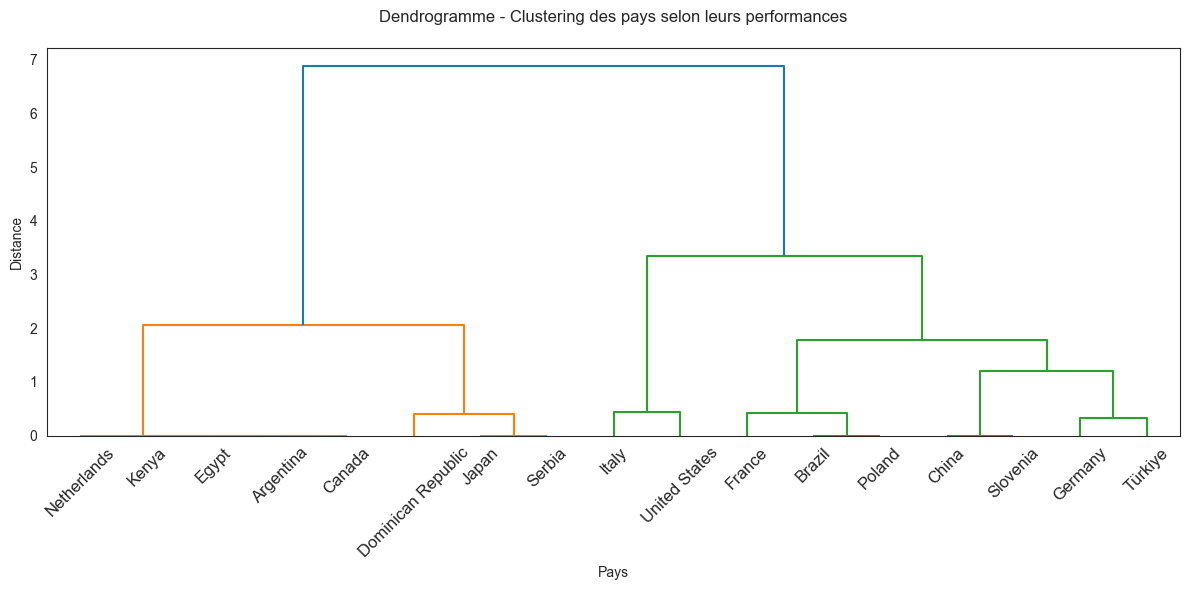

In [15]:
# Standardisation des données (nécessaire avant un clustering)
# La standardisation permet de mettre toutes les variables à la même échelle
scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_data)

# CAH avec la méthode de Ward
Z = linkage(cluster_scaled, method="ward")

# Dendrogramme
plt.figure(figsize=(12, 6))
dendrogram(Z, labels=cluster_data.index, leaf_rotation=45)
plt.title("Dendrogramme - Clustering des pays selon leurs performances\n")
plt.xlabel("Pays")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

#### Attribution des clusters et visualisation

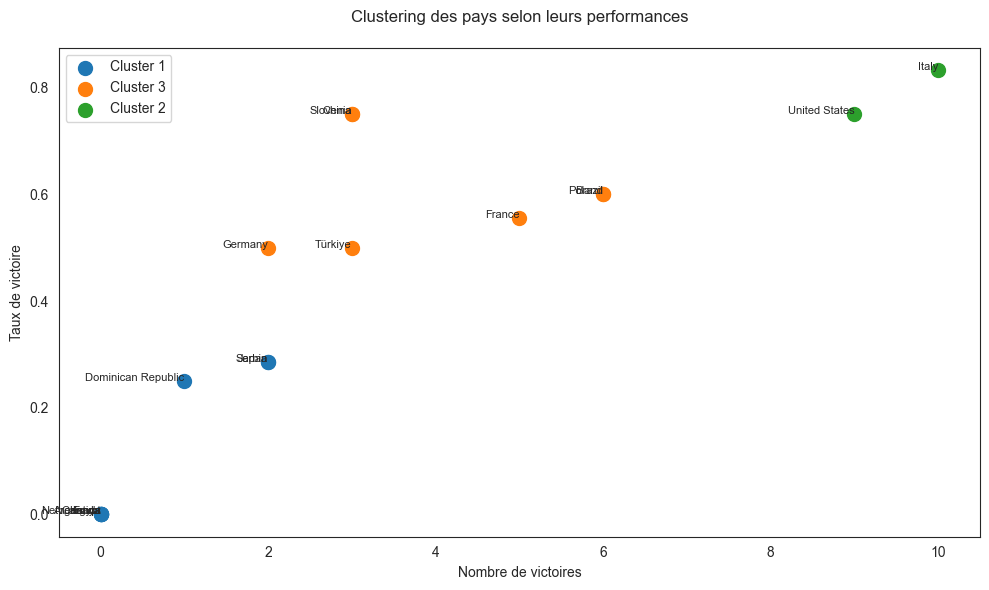

In [16]:
# Attribution des clusters (k=3 d'après le dendrogramme)
cluster_data["Cluster_hac"] = fcluster(Z, t=3, criterion="maxclust")

# Visualisation des clusters
plt.figure(figsize=(10, 6))
for cluster in cluster_data["Cluster_hac"].unique():
    subset = cluster_data[cluster_data["Cluster_hac"] == cluster]
    plt.scatter(subset["victoires"], subset["taux_victoire"], 
                label=f"Cluster {cluster}", s=100)
    for pays in subset.index:
        plt.annotate(pays, (subset.loc[pays, "victoires"], 
                    subset.loc[pays, "taux_victoire"]),
                    fontsize=8, ha="right")

plt.title("Clustering des pays selon leurs performances\n")
plt.xlabel("Nombre de victoires")
plt.ylabel("Taux de victoire")
plt.legend()
plt.tight_layout()
plt.show()

Le clustering met en évidence trois groupes distincts de pays selon leurs performances au tournoi de volleyball des JO de Paris 2024.

Le Cluster 2 regroupe les nations dominantes, représentées uniquement par l'Italie et les États-Unis. Ces deux pays se distinguent nettement des autres 
par un nombre de victoires très élevé (10 et 9) combiné à un taux de victoire supérieur à 0.75, traduisant une supériorité sportive incontestable.

Le Cluster 3 rassemble les nations compétitives, parmi lesquelles on trouve la France, le Brésil, la Pologne, la Slovénie, la Chine, l'Allemagne et la 
Turquie. Ces pays affichent des performances intermédiaires avec des taux de victoire compris entre 0.5 et 0.75, témoignant d'un niveau sportif solide 
sans pour autant atteindre l'excellence des deux leaders.

Le Cluster 1 regroupe les nations peu compétitives, notamment le Kenya, l'Égypte, l'Argentine, le Canada, les Pays-Bas, la République Dominicaine 
et la Serbie. Ces pays enregistrent peu ou pas de victoires, révélant des inégalités structurelles importantes liées au développement du volleyball 
dans ces régions du monde.

Cette classification confirme l'existence d'un "entre-soi" des grandes puissances sportives, concentrées en Europe et en Amérique, et interroge 
sur les conditions d'accès au volleyball de haut niveau pour les nations africaines.

## Conclusion générale

Cette analyse statistique du volleyball aux Jeux Olympiques de Paris 2024 a permis de mettre en évidence deux types d'inégalités structurelles qui 
traversent cette discipline sportive.

La première partie consacrée aux inégalités de genre a montré que la symétrie parfaite du format compétitif, avec 52 matchs et 12 pays dans chaque tournoi, masque des réalités plus nuancées. Si le test du Chi² confirme une distribution équivalente des victoires et défaites entre les deux genres, l'analyse des pays participants révèle que seuls 7 nations sur 19 sont présentes dans les deux tournois. Les grandes puissances historiques du volleyball dominent indépendamment du genre, tandis que certaines nations ne parviennent à se qualifier que dans un seul tournoi, traduisant des dynamiques de développement sportif différentes selon le genre.

La seconde partie consacrée au contexte géopolitique a confirmé une concentration très marquée des performances entre un petit nombre de nations. L'Europe et l'Amérique captent à elles deux 84% des victoires du tournoi, tandis que l'Afrique n'en enregistre aucune. Le clustering par CAH a permis d'identifier trois groupes distincts de pays : les nations dominantes (Italie, États-Unis), les nations compétitives (France, Brésil, Pologne...) 
et les nations peu compétitives (Kenya, Égypte, Argentine...). Cette hiérarchie reflète des inégalités structurelles profondes liées aux ressources 
économiques, aux infrastructures sportives et aux traditions nationales dans cette discipline.

Au regard de la problématique générale, le volleyball olympique apparaît ainsi comme un révélateur des inégalités sociales, politiques et de genre qui traversent le monde contemporain, confirmant que le sport de haut niveau reste le reflet des rapports de force entre nations.